In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

In [16]:
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor, Normalize, Compose
from torch.utils.data import DataLoader
import numpy as np

In [17]:
train = CIFAR10(root='cifar', train=True, transform=ToTensor(), download=False) 
test = CIFAR10(root='cifar', train=False, transform=ToTensor(), download=False) 

In [28]:
train_dataset = train
test_dataset = test

In [29]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=256, shuffle=False)

In [30]:
def get_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            #związane z pracą na GPU
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [31]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') #uzyj karty graficznej (GPU) do obliczen, Podczas trenowania sieci neuronowych wykonuje się bardzo dużo równoległych operacji na macierzach. GPU są zoptymalizowane do takich obliczeń, dlatego znacząco przyspieszają proces uczenia w porównaniu do CPU.

#Parametry do trenowania 
num_epochs = 20
num_classes = 10 
learning_rate = 0.001


# Nasza sieć konwolucyjna (dwuwarstwowa)
class ConvNet(nn.Module):
    def __init__(self, num_classes):
        super(ConvNet, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(6),  # normalizacja
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(6, 5, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.fc1 = nn.Linear(8*8*5, 7) #to oczywiscie mozna rozbudowac :)
        self.fc2 = nn.Linear(7, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = F.relu(self.fc1(out))
        out = self.fc2(out)
        return out


# budujemy model
model = ConvNet(num_classes).to(device)

# funkcja kosztu i optymalizator
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) ##SGD (Stochastic Gradient Descent) używa stałego współczynnika uczenia dla wszystkich parametrów, natomiast Adam automatycznie dostosowuje krok uczenia dla każdego parametru na podstawie średniej i wariancji gradientów, co zwykle przyspiesza i stabilizuje trening.

Epoch 1/20, Loss: 2.0614, Train Acc: 0.2974, Val Acc: 0.2890
Epoch 2/20, Loss: 1.6789, Train Acc: 0.3831, Val Acc: 0.3781
Epoch 3/20, Loss: 1.5740, Train Acc: 0.3368, Val Acc: 0.3386
Epoch 4/20, Loss: 1.5137, Train Acc: 0.3775, Val Acc: 0.3718
Epoch 5/20, Loss: 1.4659, Train Acc: 0.4374, Val Acc: 0.4372
Epoch 6/20, Loss: 1.4253, Train Acc: 0.4000, Val Acc: 0.3944
Epoch 7/20, Loss: 1.3880, Train Acc: 0.4558, Val Acc: 0.4507
Epoch 8/20, Loss: 1.3639, Train Acc: 0.5030, Val Acc: 0.4979
Epoch 9/20, Loss: 1.3454, Train Acc: 0.4631, Val Acc: 0.4609
Epoch 10/20, Loss: 1.3220, Train Acc: 0.4024, Val Acc: 0.4005
Epoch 11/20, Loss: 1.3124, Train Acc: 0.4438, Val Acc: 0.4333
Epoch 12/20, Loss: 1.3049, Train Acc: 0.4475, Val Acc: 0.4427
Epoch 13/20, Loss: 1.2909, Train Acc: 0.4859, Val Acc: 0.4873
Epoch 14/20, Loss: 1.2815, Train Acc: 0.5200, Val Acc: 0.5099
Epoch 15/20, Loss: 1.2756, Train Acc: 0.4813, Val Acc: 0.4690
Epoch 16/20, Loss: 1.2665, Train Acc: 0.4885, Val Acc: 0.4774
Epoch 17/20, Loss

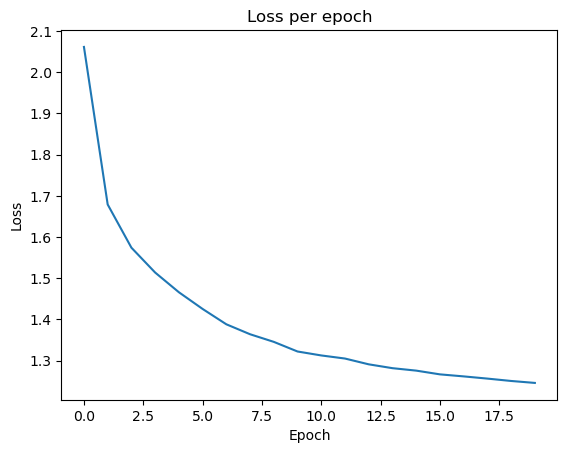

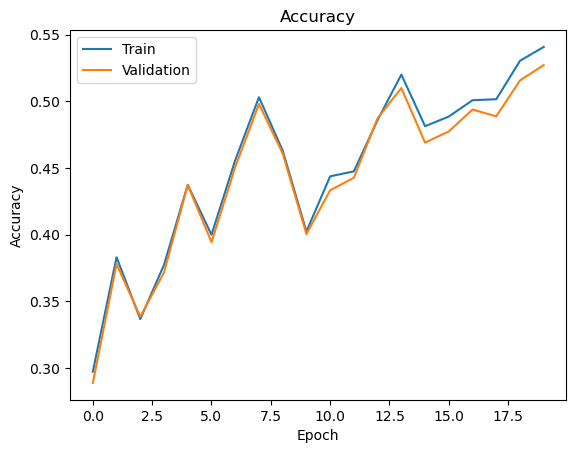

In [32]:
losses = []
train_acc = []
val_acc = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        #związane z pracą na GPU
        images = images.to(device)
        labels = labels.to(device)

        #Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        #Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    #średnia strata z epoki
    epoch_loss = running_loss / len(train_loader)
    losses.append(epoch_loss)

    #dokładność
    train_accuracy = get_accuracy(model, train_loader)
    val_accuracy = get_accuracy(model, val_loader)

    train_acc.append(train_accuracy)
    val_acc.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, "
          f"Train Acc: {train_accuracy:.4f}, Val Acc: {val_accuracy:.4f}")

#Funkcja kosztu
plt.plot(losses)
plt.title("Loss per epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

#Dokładność
plt.plot(train_acc, label="Train")
plt.plot(val_acc, label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [33]:
test_accuracy = get_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.5197
